### liner regression

In [127]:
# house price dataset
from sklearn.datasets import fetch_california_housing
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [128]:
housing = fetch_california_housing()

In [129]:
type(housing)

sklearn.utils._bunch.Bunch

In [130]:
housing

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [131]:
dataset =pd.DataFrame(housing.data, columns=housing.feature_names).head()

In [132]:
dataset

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [133]:
import pandas as pd
from sklearn.datasets import fetch_california_housing


housing = fetch_california_housing()
dataset = pd.DataFrame(
    housing.data,
    columns=housing.feature_names
)


dataset["price"] = housing.target


print(dataset.shape)
print(dataset.head())

(20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  price  
0    -122.23  4.526  
1    -122.22  3.585  
2    -122.24  3.521  
3    -122.25  3.413  
4    -122.25  3.422  


## dividing the dataset into independent and dependent fetures

In [134]:
X = dataset.iloc[:, :-1]
y = dataset.iloc[:, -1]

In [135]:
X.head()
y.head()

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: price, dtype: float64

### linear regression

In [136]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

lin_reg = LinearRegression()

mse = cross_val_score(
    lin_reg,
    X,
    y,
    scoring='neg_mean_squared_error',
    cv=5
)
mean_mse=np.mean(mse)

print(mean_mse)

-0.5582901717686554


### RIDGE regression

In [137]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

ridge = Ridge()

params = {
    "alpha": [0.1, 1, 10, 100]
}

ridge_regressor = GridSearchCV(
    ridge,
    params,
    scoring="neg_mean_squared_error",
    cv=5
)

ridge_regressor.fit(X, y)

print("Best Alpha:", ridge_regressor.best_params_)
print("Best Score:", ridge_regressor.best_score_)

Best Alpha: {'alpha': 100}
Best Score: -0.5579724434119415


### lasso-l1 regularization

In [138]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV


lasso = Lasso()


params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
}


lasso_regressor = GridSearchCV(
    lasso,
    params,
    scoring="neg_mean_squared_error",
    cv=5
)


lasso_regressor.fit(X, y)


print("Best Alpha:", lasso_regressor.best_params_)
print("Best Score:", lasso_regressor.best_score_)

Best Alpha: {'alpha': 0.001}
Best Score: -0.5582759293868985


In [139]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score


X, y = load_diabetes(return_X_y=True)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)


lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

print("Ridge R²:", r2_score(y_test, ridge_pred))
print("Lasso R²:", r2_score(y_test, lasso_pred))

print("Ridge Coefficients:")
print(ridge.coef_)

print("Lasso Coefficients:")
print(lasso.coef_)

Ridge R²: 0.41915292635986545
Lasso R²: 0.4718547867276227
Ridge Coefficients:
[  45.36737726  -76.66608563  291.33883165  198.99581745   -0.53030959
  -28.57704987 -144.51190505  119.26006559  230.22160832  112.14983004]
Lasso Coefficients:
[   0.         -152.66477923  552.69777529  303.36515791  -81.36500664
   -0.         -229.25577639    0.          447.91952518   29.64261704]


## comparing with all regression models

In [140]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": ridge_regressor.best_estimator_,
    "Lasso Regression": lasso_regressor.best_estimator_
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {
        "MSE": mse,
        "R2 Score": r2
    }

for model, scores in results.items():
    print("\n", model)
    print("MSE:", scores["MSE"])
    print("R2 Score:", scores["R2 Score"])


 Linear Regression
MSE: 2900.1936284934804
R2 Score: 0.4526027629719197

 Ridge Regression
MSE: 5233.663686578425
R2 Score: 0.012171803489062438

 Lasso Regression
MSE: 2896.4097872031957
R2 Score: 0.4533169443449512


## feature scaling

In [141]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

Rdige regression scaling

In [142]:
ridge = Ridge()

ridge_regressor = GridSearchCV(
    ridge,
    params,
    scoring="neg_mean_squared_error",
    cv=5
)

ridge_regressor.fit(X_train_scaled, y_train)

ridge_pred = ridge_regressor.predict(X_test_scaled)

print("Ridge MSE:",
      mean_squared_error(y_test, ridge_pred))

print("Ridge R2:",
      r2_score(y_test, ridge_pred))

Ridge MSE: 2875.778718421843
Ridge R2: 0.45721095677808476


## lasso

In [143]:
lasso = Lasso()

lasso_regressor = GridSearchCV(
    lasso,
    params,
    scoring="neg_mean_squared_error",
    cv=5
)

lasso_regressor.fit(X_train_scaled, y_train)

lasso_pred = lasso_regressor.predict(X_test_scaled)

print("Lasso MSE:",
      mean_squared_error(y_test, lasso_pred))

print("Lasso R2:",
      r2_score(y_test, lasso_pred))

Lasso MSE: 2824.568094049959
Lasso R2: 0.46687670944102466


## visualization

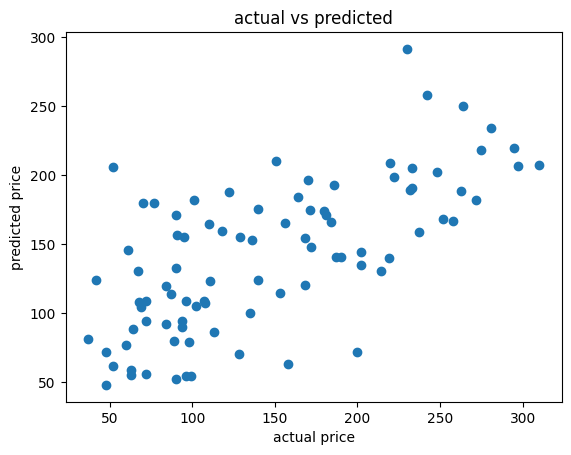

In [144]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.xlabel("actual price")
plt.ylabel("predicted price")
plt.title("actual vs predicted")
plt.show()

## best fit or best model

In [145]:
import pickle


best_lasso = lasso_regressor.best_estimator_

with open("house_price_model.pkl", "wb") as file:
    pickle.dump(best_lasso, file)

print("Model saved successfully")

Model saved successfully
